# DRL-Based Portfolio Management: State, Action, and Reward

## **1. State (s)**
The *state* represents the information available to the agent at each time step. It consists of:
- *Current asset prices* (normalized).
- *Previous portfolio weights* (distribution of capital across assets).

### *Mathematical Representation*
At time $t$:

$$
    s_t = \left[ \tilde{P}t, W{t-1} \right]
$$

where:
- $\tilde{P}t = \frac{\tilde{P}{t-1}}{\tilde{P}_t}$. $\tilde{P}_t $ represents the normalized price, indicating the relative price change.
- $W_{t-1}$ is the vector of portfolio weights from the previous step.

💡 *State evolution*:
As the agent interacts with the market, new states are generated based on:
1. *Current window prices*  (normalized).
2. *Portfolio rebalancing results* (agent’s actions).
---

## **2. Action (a)**
The *action* determines how the agent rebalances the portfolio. The agent decides:
- How much capital to allocate to each asset.
- Adjustments to previous weights.

### *Mathematical Representation*
$$
    a_t \in [-1,1]^N
$$

where:
- $a_t$ is a vector with $N$ elements, where $N$ is the number of assets.
- $a_t$ represents an *adjustment* to the previous weight allocation suggested by the agent (The agent does *not directly* choose portfolio weights but *adjusts* them incrementally.).

Each element $a_t[i]$ follows:
- $a_t[i] = 0$ → No change in allocation for asset $i$.
- $a_t[i] > 0$ → Increase investment in asset $i$.
- $a_t[i] < 0$ → Decrease investment in asset $i$.

After the action is taken:

$$
    W_t = W_{t-1} + a_t
$$

Portfolio weights are normalized to *1* (i.e., 100% capital allocation).


---

## **3. Reward (r)**
The *reward function* evaluates the agent’s portfolio performance by considering:
1. *Portfolio Return $R_t$* (growth of the portfolio).
2. *Transaction Cost $C_t$* (costs from adjusting weights).
3. *Risk Penalty $V_t$* (to discourage high volatility).

### *Mathematical Representation*

#### *-Portfolio Return:*
$$
    R_t = W_t^T r_t
$$
where:
- $r_t$ is the asset return vector at time $t$.
- $W_t$ is the portfolio weight vector.

#### *-Transaction Cost:*
$$
    C_t = \xi \sum | W_t - W_{t-1} |
$$
where $\xi$ is a *transaction cost parameter*.

#### *-Risk Penalty:*
$$
    V_t = \beta \text{Var}(R_{t-\text{window}:t})
$$
where $\beta$ is a *risk aversion coefficient*.

#### *-Total Reward Function:*
$$
    r_t = R_t - C_t - V_t
$$

💡 The *agent receives immediate rewards* based on portfolio performance after executing an action.

---

## *🔹 Summary*
| Component | Description |
|-----------|------------|
| **State (s)** | Asset prices (normalized) + previous portfolio weights |
| **Action (a)** | Adjustments to portfolio allocation |
| **Reward (r)** | Portfolio return - transaction costs - risk penalty |

Using device: cuda
Train shape: (2604, 95)
Test shape: (652, 95)
Starting training...
Episode: 0, Reward: 0.9268, Final Value: 1.9268
Episode: 1, Reward: 1.9008, Final Value: 2.9008
Episode: 2, Reward: 1.8309, Final Value: 2.8309
Episode: 3, Reward: 1.9707, Final Value: 2.9707
Episode: 4, Reward: 1.9619, Final Value: 2.9619
Episode: 5, Reward: 1.8771, Final Value: 2.8771
Episode: 6, Reward: 2.2755, Final Value: 3.2755
Episode: 7, Reward: 2.6854, Final Value: 3.6854
Episode: 8, Reward: 2.5714, Final Value: 3.5714
Episode: 9, Reward: 2.5571, Final Value: 3.5571
Episode: 10, Reward: 2.6204, Final Value: 3.6204
Episode: 11, Reward: 2.2719, Final Value: 3.2719
Episode: 12, Reward: 2.4715, Final Value: 3.4715
Episode: 13, Reward: 2.7738, Final Value: 3.7738
Episode: 14, Reward: 2.7771, Final Value: 3.7771
Episode: 15, Reward: 2.3409, Final Value: 3.3409
Episode: 16, Reward: 2.1703, Final Value: 3.1703
Episode: 17, Reward: 1.9745, Final Value: 2.9745
Episode: 18, Reward: 1.8289, Final Value: 

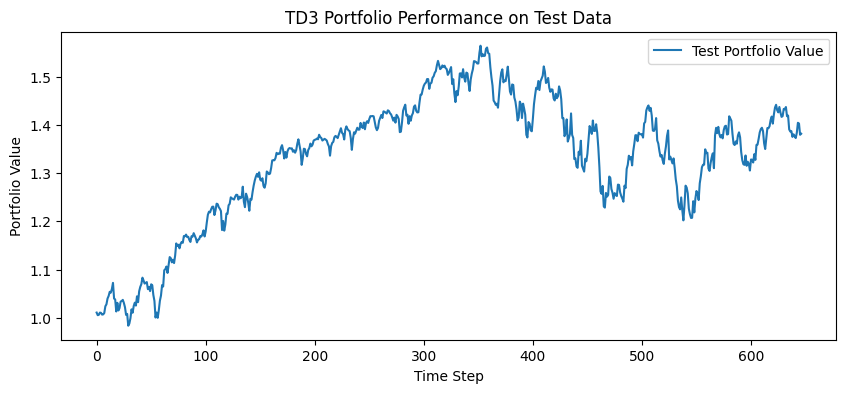

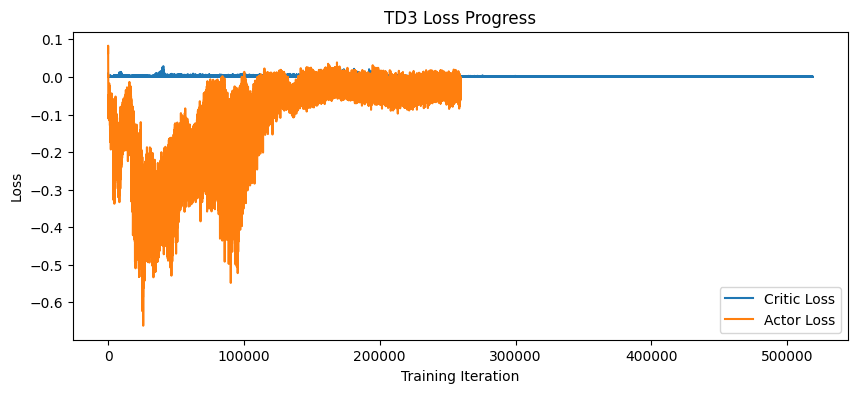

In [1]:
"""
Replicate the DRL-based portfolio selection model 
from "Deep reinforcement learning for portfolio selection" by Jiang et al.

This code uses the same hyperparameters and algorithmic details as in the paper:
  • Two hidden layers with 512 neurons each
  • Actor & Critic learning rates: 5e-5
  • Discount factor: 0.98
  • Target update rate (tau): 0.005
  • Policy noise: 0.02, noise clip: 0.05
  • Exploration noise: standard deviation 0.15
  • Mini-batch size: 64, Replay buffer size: 1e6
  • Beta (risk aversion) = 0.005
  • Xi (transaction cost rate) = 0.0005
  • Episode = 200
"""

# -------------------------- 1. Libraries and Device Setup --------------------------
import numpy as np
import pandas as pd
import gym
from gym import spaces
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# For reproducibility 
SEED = 123
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -------------------------- 2. Data Loading --------------------------
data_path = "cleaned_closing_prices.csv"
data = pd.read_csv(data_path, parse_dates=[0], index_col=0).sort_index()

# Fill missing values in the time series data:
data.ffill(inplace=True) # Fill NaNs with the previous valid value
data.bfill(inplace=True) # Fill remaining NaNs (if any) with the next valid value

# Normalize prices by dividing by the previous day's closing price
data = data.div(data.shift(1), axis=0).fillna(1)

# Use normalized data for training and testing
train_ratio = 0.8
split_idx = int(len(data) * train_ratio)
df_train = data.iloc[:split_idx]
df_test = data.iloc[split_idx:]

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

# -------------------------- 3. Portfolio Environment --------------------------
class PortfolioEnv(gym.Env):
    def __init__(self, data, initial_cash=1.0, beta=0.005, xi=0.0005, window=5):
        """
        data: DataFrame of shape (T, N), with daily prices for N assets 
        initial_cash: starting portfolio value (P0) 
        beta: risk aversion coefficient (penalizes volatility) 
        xi: transaction cost rate (as a fraction) 
        window: window: number of recent days used to compute risk (sample variance) 
        """
        super().__init__()
        self.data_df = data.copy()
        self.data = self.data_df.values  # shape (T, N)
        self.num_assets = self.data.shape[1]
        self.initial_cash = initial_cash
        self.beta = beta
        self.xi = xi
        self.window = window
        
        self.current_step = window
        self.done = False
        self.portfolio_value = self.initial_cash
        
        # Start with equal weights
        self.prev_weights = np.ones(self.num_assets) / self.num_assets
        
        # Action space: continuous in [-1,1] for each asset
        self.action_space = spaces.Box(low=-1, high=1, shape=(self.num_assets,), dtype=np.float32)
        
        # Observation space: current prices (normalized) + previous weights
        self.observation_space = spaces.Box(
            low=0, high=np.inf, shape=(self.num_assets * 2,), dtype=np.float32
        )

    def reset(self):
        self.current_step = self.window
        self.done = False
        self.portfolio_value = self.initial_cash
        self.prev_weights = np.ones(self.num_assets) / self.num_assets
        return self._get_obs()
    
    def _get_obs(self):
        normalized_prices = np.cumprod(self.data[:self.current_step + 1], axis=0)[-1]
        return np.concatenate([normalized_prices, self.prev_weights])

    def step(self, action):
        # 1) Update weights
        new_weights = self.prev_weights + action
        new_weights = np.clip(new_weights, 0, None)
        if new_weights.sum() == 0:
            new_weights = self.prev_weights
        else:
            new_weights = new_weights / new_weights.sum()
        
        # 2) Transaction cost
        transaction_cost = self.xi * self.portfolio_value * np.sum(np.abs(new_weights - self.prev_weights))
        
        # 3) Portfolio return
        prev_prices = self.data[self.current_step - 1]
        current_prices = self.data[self.current_step]
        asset_returns = current_prices - 1  # now data already represents daily return
        portfolio_return = np.dot(self.prev_weights, asset_returns)

        # 4) Risk penalty (variance of recent returns)
        recent_returns = []
        for i in range(self.current_step - self.window, self.current_step):
            r = (self.data[i] - self.data[i-1]) / self.data[i-1]
            recent_returns.append(np.dot(self.prev_weights, r))
        risk = np.var(recent_returns) if recent_returns else 0
        risk_cost = self.beta * risk * self.portfolio_value
        
        # 5) Reward
        reward = self.portfolio_value * portfolio_return - transaction_cost - risk_cost
        
        # 6) Update portfolio value
        self.portfolio_value = self.portfolio_value * (1 + portfolio_return) - transaction_cost - risk_cost
        
        # 7) Update weights
        self.prev_weights = new_weights
        
        # 8) Next step
        self.current_step += 1
        if self.current_step >= len(self.data):
            self.done = True
        
        obs = self._get_obs() if not self.done else np.zeros(self.observation_space.shape, dtype=np.float32)
        info = {"portfolio_value": self.portfolio_value}
        return obs, reward, self.done, info

# -------------------------- 4. Replay Buffer --------------------------
class ReplayBuffer:
    def __init__(self, state_dim, action_dim, max_size=int(1e6)):
        self.max_size = max_size
        self.ptr = 0
        self.size = 0
        self.state = np.zeros((max_size, state_dim))
        self.action = np.zeros((max_size, action_dim))
        self.next_state = np.zeros((max_size, state_dim))
        self.reward = np.zeros((max_size, 1))
        self.done = np.zeros((max_size, 1))
    
    def add(self, state, action, reward, next_state, done):
        self.state[self.ptr] = state
        self.action[self.ptr] = action
        self.reward[self.ptr] = reward
        self.next_state[self.ptr] = next_state
        self.done[self.ptr] = done
        self.ptr = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)
    
    def sample(self, batch_size):
        ind = np.random.randint(0, self.size, size=batch_size)
        return (
            torch.FloatTensor(self.state[ind]).to(device),
            torch.FloatTensor(self.action[ind]).to(device),
            torch.FloatTensor(self.reward[ind]).to(device),
            torch.FloatTensor(self.next_state[ind]).to(device),
            torch.FloatTensor(self.done[ind]).to(device)
        )

# -------------------------- 5. Actor and Critic Networks --------------------------
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, max_action):
        super(Actor, self).__init__()
        self.l1 = nn.Linear(state_dim, 512)
        self.l2 = nn.Linear(512, 512)
        self.l3 = nn.Linear(512, action_dim)
        self.max_action = max_action
    
    def forward(self, state):
        a = torch.relu(self.l1(state))
        a = torch.relu(self.l2(a))
        a = torch.tanh(self.l3(a))
        return a * self.max_action

class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Critic, self).__init__()
        # Q1
        self.l1 = nn.Linear(state_dim + action_dim, 512)
        self.l2 = nn.Linear(512, 512)
        self.l3 = nn.Linear(512, 1)
        # Q2
        self.l4 = nn.Linear(state_dim + action_dim, 512)
        self.l5 = nn.Linear(512, 512)
        self.l6 = nn.Linear(512, 1)
    
    def forward(self, state, action):
        sa = torch.cat([state, action], 1)
        q1 = torch.relu(self.l1(sa))
        q1 = torch.relu(self.l2(q1))
        q1 = self.l3(q1)
        
        q2 = torch.relu(self.l4(sa))
        q2 = torch.relu(self.l5(q2))
        q2 = self.l6(q2)
        return q1, q2
    
    def Q1(self, state, action):
        sa = torch.cat([state, action], 1)
        q1 = torch.relu(self.l1(sa))
        q1 = torch.relu(self.l2(q1))
        q1 = self.l3(q1)
        return q1

# -------------------------- 6. TD3 Agent --------------------------
class TD3:
    def __init__(self, state_dim, action_dim, max_action, discount=0.98, tau=0.005,
                 policy_noise=0.02, noise_clip=0.05, policy_freq=2):
        self.actor = Actor(state_dim, action_dim, max_action).to(device)
        self.actor_target = Actor(state_dim, action_dim, max_action).to(device)
        self.actor_target.load_state_dict(self.actor.state_dict())
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=5e-5)
        
        self.critic = Critic(state_dim, action_dim).to(device)
        self.critic_target = Critic(state_dim, action_dim).to(device)
        self.critic_target.load_state_dict(self.critic.state_dict())
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=5e-5)
        
        self.max_action = max_action
        self.discount = discount
        self.tau = tau
        self.policy_noise = policy_noise
        self.noise_clip = noise_clip
        self.policy_freq = policy_freq
        self.total_it = 0
        
        # Track training losses for plotting
        self.train_log = {
            "critic_loss": [],
            "actor_loss": []
        }
    
    def select_action(self, state):
        state = torch.FloatTensor(state.reshape(1, -1)).to(device)
        return self.actor(state).cpu().data.numpy().flatten()
    
    def train(self, replay_buffer, batch_size=64):
        self.total_it += 1
        state, action, reward, next_state, done = replay_buffer.sample(batch_size)
        
        # Target policy smoothing
        noise = (torch.randn_like(action) * self.policy_noise).clamp(-self.noise_clip, self.noise_clip)
        next_action = (self.actor_target(next_state) + noise).clamp(-self.max_action, self.max_action)
        
        # Target Q
        target_Q1, target_Q2 = self.critic_target(next_state, next_action)
        target_Q = torch.min(target_Q1, target_Q2)
        target_Q = reward + ((1 - done) * self.discount * target_Q).detach()
        
        # Current Q
        current_Q1, current_Q2 = self.critic(state, action)
        critic_loss = nn.MSELoss()(current_Q1, target_Q) + nn.MSELoss()(current_Q2, target_Q)
        
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()
        
        self.train_log["critic_loss"].append(critic_loss.item())
        
        # Delayed actor update
        if self.total_it % self.policy_freq == 0:
            actor_loss = -self.critic.Q1(state, self.actor(state)).mean()
            self.actor_optimizer.zero_grad()
            actor_loss.backward()
            self.actor_optimizer.step()
            
            self.train_log["actor_loss"].append(actor_loss.item())
            
            # Polyak averaging
            for param, target_param in zip(self.actor.parameters(), self.actor_target.parameters()):
                target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)
            for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
                target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

# -------------------------- 7. Training Loop --------------------------
def train_td3(env, td3_agent, replay_buffer, episodes=200, max_timesteps=1000, batch_size=64, start_timesteps=1000):
    total_steps = 0
    for episode in range(episodes):
        state = env.reset()
        episode_reward = 0
        for t in range(max_timesteps):
            total_steps += 1
            # Random exploration until start_timesteps
            if total_steps < start_timesteps:
                action = env.action_space.sample()
            else:
                action = td3_agent.select_action(state)
                # Gaussian exploration noise
                action = (action + np.random.normal(0, 0.15, size=env.action_space.shape[0])).clip(env.action_space.low, env.action_space.high)
            
            next_state, reward, done, info = env.step(action)
            replay_buffer.add(state, action, reward, next_state, float(done))
            state = next_state
            episode_reward += reward
            
            if total_steps >= start_timesteps:
                td3_agent.train(replay_buffer, batch_size)
            
            if done:
                break
        
        print(f"Episode: {episode}, Reward: {episode_reward:.4f}, Final Value: {info.get('portfolio_value', 0):.4f}")

# -------------------------- 8. Main Execution --------------------------
if __name__ == "__main__":
    # Create training environment
    train_env = PortfolioEnv(df_train, beta=0.005, xi=0.0005, window=5)
    state_dim = train_env.observation_space.shape[0]
    action_dim = train_env.action_space.shape[0]
    max_action = 1.0
    
    # Initialize agent and replay buffer
    replay_buffer = ReplayBuffer(state_dim, action_dim)
    td3_agent = TD3(state_dim, action_dim, max_action)
    
    # Train
    print("Starting training...")
    train_td3(train_env, td3_agent, replay_buffer,
              episodes=200,
              max_timesteps=len(df_train) - 5,
              batch_size=64,
              start_timesteps=1000)
    
    # -------------------------- Evaluate on Test Set --------------------------
    test_env = PortfolioEnv(df_test, beta=0.005, xi=0.0005, window=5)
    state = test_env.reset()
    done = False
    portfolio_values = []
    while not done:
        action = td3_agent.select_action(state)
        state, reward, done, info = test_env.step(action)
        portfolio_values.append(info["portfolio_value"])
    
    # Plot final test portfolio value progression
    plt.figure(figsize=(10,4))
    plt.plot(portfolio_values, label="Test Portfolio Value")
    plt.title("TD3 Portfolio Performance on Test Data")
    plt.xlabel("Time Step")
    plt.ylabel("Portfolio Value")
    plt.legend()
    plt.show()
    
    # -------------------------- Plot Training Losses --------------------------
    plt.figure(figsize=(10,4))
    plt.plot(td3_agent.train_log["critic_loss"], label="Critic Loss")
    plt.plot(td3_agent.train_log["actor_loss"], label="Actor Loss")
    plt.title("TD3 Loss Progress")
    plt.xlabel("Training Iteration")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

In [7]:
# -------------------------- 9. Define Performance Metrics Calculation --------------------------
def compute_metrics(portfolio_values, trading_days=252):
    """
    Compute key performance metrics based on portfolio values over time.

    Parameters:
        portfolio_values (list or np.array): Daily portfolio values.
        trading_days (int): Number of trading days per year (default is 252).

    Returns:
        dict: A dictionary containing the computed performance metrics.
    """
    portfolio_values = np.array(portfolio_values)
    initial_value = portfolio_values[0]
    final_value = portfolio_values[-1]
    
    # 1) Cumulative Return: (Final - Initial) / Initial
    cumulative_return = (final_value - initial_value) / initial_value
    
    # 2) Annualized Return: (final/initial)^(trading_days/num_periods) - 1
    num_periods = len(portfolio_values)
    annualized_return = (final_value / initial_value) ** (trading_days / num_periods) - 1
    
    # 3) Compute Daily Returns
    daily_returns = portfolio_values[1:] / portfolio_values[:-1] - 1
    
    # 4) Annualized Volatility: Standard deviation of daily returns scaled by sqrt(trading_days)
    annual_volatility = np.std(daily_returns) * np.sqrt(trading_days)
    
    # 5) Sharpe Ratio (assuming zero risk-free rate)
    sharpe_ratio = annualized_return / annual_volatility if annual_volatility != 0 else np.nan
    
    # 6) Maximum Drawdown: Maximum drop from a running maximum
    cumulative_max = np.maximum.accumulate(portfolio_values)
    drawdowns = (portfolio_values - cumulative_max) / cumulative_max
    max_drawdown = drawdowns.min()  # Will be negative
    
    # 7) Calmar Ratio: Annualized return divided by the absolute maximum drawdown
    calmar_ratio = annualized_return / abs(max_drawdown) if max_drawdown != 0 else np.nan
    
    return {
        "Cumulative Return": cumulative_return,
        "Annualized Return": annualized_return,
        "Annual Volatility": annual_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": max_drawdown,
        "Calmar Ratio": calmar_ratio
    }

# -------------------------- Compute and Display Performance Metrics --------------------------
# Print the first 10 portfolio values to check for anomalies
print("First 10 portfolio values:", portfolio_values[:10])

# Compute performance metrics based on portfolio values
metrics = compute_metrics(portfolio_values)

# Print performance results
print("Performance Metrics:")
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")


First 10 portfolio values: [1.0106817755995734, 1.0052682047843868, 1.0059581221655594, 1.0105889430190653, 1.0100931684032122, 1.0064377935342763, 1.0068367481544926, 1.0096925495251992, 1.0237407696564171, 1.0278412086776245]
Performance Metrics:
Cumulative Return: 0.3672
Annualized Return: 0.1296
Annual Volatility: 0.1876
Sharpe Ratio: 0.6905
Maximum Drawdown: -0.2317
Calmar Ratio: 0.5593


# Baseline Model Comparison with DRL


In [9]:
import numpy as np
import pandas as pd
import scipy.optimize as opt
import matplotlib.pyplot as plt

# -------------------------- 1. Mean-Variance Optimization Strategy --------------------------
def minimum_variance_strategy(env, window=5):
    """
    Mean-variance optimization strategy based on Markowitz's modern portfolio theory.
    
    Parameters:
        data (pd.DataFrame): DataFrame of shape (T, N), with daily prices for N assets.
        risk_aversion (float): Risk aversion coefficient.
        window (int): Window size for calculating expected returns and covariance matrix.
    
    Returns:
        portfolio_values (list): List of portfolio values over time.
    """
    state = env.reset()
    done = False
    portfolio_values = []
    while not done:
        # Calculate the covariance matrix using the past window days of data
        recent_returns = env.data[env.current_step - window:env.current_step]
        cov_matrix = np.cov(recent_returns, rowvar=False)
        
        # Objective function to minimize variance
        def objective(weights):
            return weights.T @ cov_matrix @ weights
        
        # Constraint: Sum of weights must be 1
        constraints = ({'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1})
        bounds = [(0, 1) for _ in range(env.num_assets)]
        initial_guess = np.ones(env.num_assets) / env.num_assets
        
        # Optimization
        result = opt.minimize(objective, initial_guess, method='SLSQP', bounds=bounds, constraints=constraints)
        action = result.x
        
        state, reward, done, info = env.step(action)
        portfolio_values.append(info["portfolio_value"])
    return portfolio_values

# -------------------------- 2. Max Sharpe Ratio Strategy --------------------------
def maximum_sharpe_ratio_strategy(env, window=5, risk_free_rate=0.000198):
    """
    Maximum Sharpe Ratio strategy based on Markowitz's modern portfolio theory.
    
    This strategy aims to maximize the Sharpe Ratio, which is the ratio of the portfolio's
    excess return (over the risk-free rate) to its volatility (standard deviation).
    
    Parameters:
        data (pd.DataFrame): DataFrame of shape (T, N), with daily prices for N assets.
        risk_free_rate (float): Risk-free rate of return (default is 0.0).
        window (int): Window size for calculating expected returns and covariance matrix.
    
    Returns:
        portfolio_values (list): List of portfolio values over time.
    """
    state = env.reset()
    done = False
    portfolio_values = []
    while not done:
        # Calculate the covariance matrix and expected returns using the past window days of data
        recent_returns = env.data[env.current_step - window:env.current_step]
        cov_matrix = np.cov(recent_returns, rowvar=False)
        expected_returns = np.mean(recent_returns, axis=0)
        
        # Objective function to maximize Sharpe ratio
        def objective(weights):
            portfolio_return = np.dot(weights, expected_returns)
            portfolio_volatility = np.sqrt(weights.T @ cov_matrix @ weights)
            sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility
            return -sharpe_ratio  # Negative sign because we want to maximize Sharpe ratio
        
        # Constraint: Sum of weights must be 1
        constraints = ({'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1})
        bounds = [(0, 1) for _ in range(env.num_assets)]
        initial_guess = np.ones(env.num_assets) / env.num_assets
        
        # Optimization
        result = opt.minimize(objective, initial_guess, method='SLSQP', bounds=bounds, constraints=constraints)
        action = result.x
        
        state, reward, done, info = env.step(action)
        portfolio_values.append(info["portfolio_value"])
    return portfolio_values

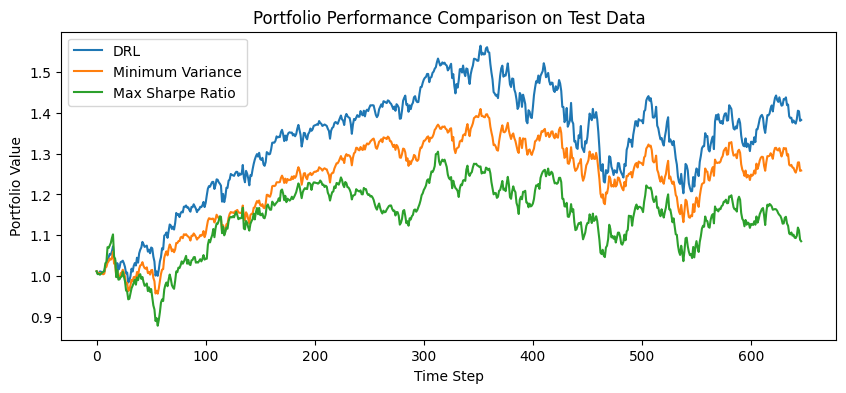

DRL Performance Metrics:
Cumulative Return: 0.3681
Annualized Return: 0.1298
Annual Volatility: 0.1876
Sharpe Ratio: 0.6920
Maximum Drawdown: -0.2315
Calmar Ratio: 0.5608

Minimum Variance Performance Metrics:
Cumulative Return: 0.2447
Annualized Return: 0.0890
Annual Volatility: 0.1543
Sharpe Ratio: 0.5768
Maximum Drawdown: -0.1972
Calmar Ratio: 0.4514

Max Sharpe Ratio Performance Metrics:
Cumulative Return: 0.0730
Annualized Return: 0.0278
Annual Volatility: 0.1846
Sharpe Ratio: 0.1507
Maximum Drawdown: -0.2061
Calmar Ratio: 0.1350


In [10]:
# -------------------------- 3. Compare Strategies --------------------------
# Performance of the DRL model on the test set
test_env = PortfolioEnv(df_test, beta=0.004, xi=0.0004, window=5)
state = test_env.reset()
done = False
portfolio_values_drl = []
while not done:
    action = td3_agent.select_action(state)
    state, reward, done, info = test_env.step(action)
    portfolio_values_drl.append(info["portfolio_value"])

# Performance of the minimum variance portfolio on the test set
test_env = PortfolioEnv(df_test, beta=0.004, xi=0.0004, window=5)
portfolio_values_min_var = minimum_variance_strategy(test_env)

# Performance of the maximum Sharpe ratio portfolio on the test set
test_env_1 = PortfolioEnv(df_test, beta=0.004, xi=0.0004, window=5)
portfolio_values_max_sharpe = maximum_sharpe_ratio_strategy(test_env_1)

# Plot comparison
plt.figure(figsize=(10,4))
plt.plot(portfolio_values_drl, label="DRL")
plt.plot(portfolio_values_min_var, label="Minimum Variance")
plt.plot(portfolio_values_max_sharpe, label="Max Sharpe Ratio")
plt.title("Portfolio Performance Comparison on Test Data")
plt.xlabel("Time Step")
plt.ylabel("Portfolio Value")
plt.legend()
plt.show()

# -------------------------- 4. Compute Performance Metrics for All Strategies --------------------------
metrics_drl = compute_metrics(portfolio_values_drl)
metrics_min_var = compute_metrics(portfolio_values_min_var)
metrics_max_sharpe = compute_metrics(portfolio_values_max_sharpe)

print("DRL Performance Metrics:")
for key, value in metrics_drl.items():
    print(f"{key}: {value:.4f}")

print("\nMinimum Variance Performance Metrics:")
for key, value in metrics_min_var.items():
    print(f"{key}: {value:.4f}")

print("\nMax Sharpe Ratio Performance Metrics:")
for key, value in metrics_max_sharpe.items():
    print(f"{key}: {value:.4f}")


# Parameter Trials


Performance Metrics for beta=0.005, xi=0.05:
Cumulative Return: 0.1055
Annualized Return: 0.0398
Annual Volatility: 0.1877
Sharpe Ratio: 0.2122
Maximum Drawdown: -0.2755
Calmar Ratio: 0.1446

Performance Metrics for beta=0.005, xi=0.01:
Cumulative Return: 0.3126
Annualized Return: 0.1118
Annual Volatility: 0.1876
Sharpe Ratio: 0.5957
Maximum Drawdown: -0.2403
Calmar Ratio: 0.4652

Performance Metrics for beta=0.005, xi=0.005:
Cumulative Return: 0.3411
Annualized Return: 0.1211
Annual Volatility: 0.1876
Sharpe Ratio: 0.6455
Maximum Drawdown: -0.2358
Calmar Ratio: 0.5137

Performance Metrics for beta=0.005, xi=0.001:
Cumulative Return: 0.3643
Annualized Return: 0.1286
Annual Volatility: 0.1876
Sharpe Ratio: 0.6855
Maximum Drawdown: -0.2321
Calmar Ratio: 0.5541


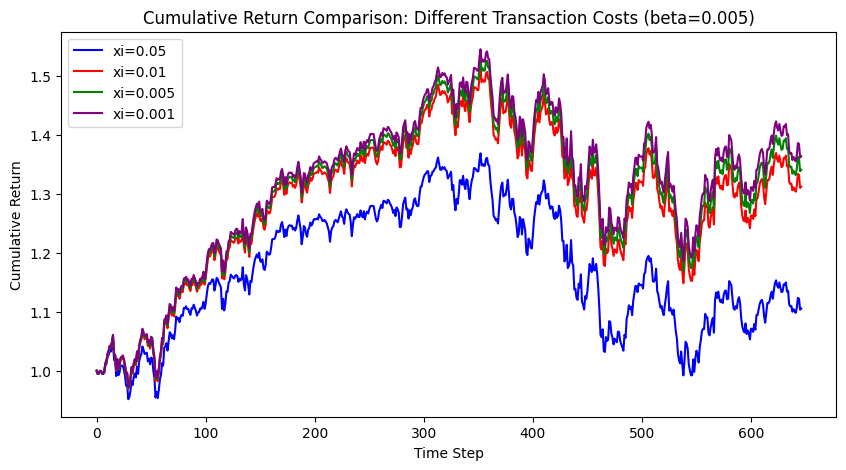


Performance Metrics for beta=0.9, xi=0.0005:
Cumulative Return: 0.1714
Annualized Return: 0.0636
Annual Volatility: 0.1876
Sharpe Ratio: 0.3389
Maximum Drawdown: -0.2795
Calmar Ratio: 0.2274

Performance Metrics for beta=0.5, xi=0.0005:
Cumulative Return: 0.2552
Annualized Return: 0.0926
Annual Volatility: 0.1876
Sharpe Ratio: 0.4935
Maximum Drawdown: -0.2585
Calmar Ratio: 0.3581

Performance Metrics for beta=0.1, xi=0.0005:
Cumulative Return: 0.3450
Annualized Return: 0.1224
Annual Volatility: 0.1876
Sharpe Ratio: 0.6522
Maximum Drawdown: -0.2369
Calmar Ratio: 0.5166

Performance Metrics for beta=0.05, xi=0.0005:
Cumulative Return: 0.3567
Annualized Return: 0.1262
Annual Volatility: 0.1876
Sharpe Ratio: 0.6724
Maximum Drawdown: -0.2341
Calmar Ratio: 0.5388

Performance Metrics for beta=0.01, xi=0.0005:
Cumulative Return: 0.3661
Annualized Return: 0.1292
Annual Volatility: 0.1876
Sharpe Ratio: 0.6885
Maximum Drawdown: -0.2319
Calmar Ratio: 0.5570


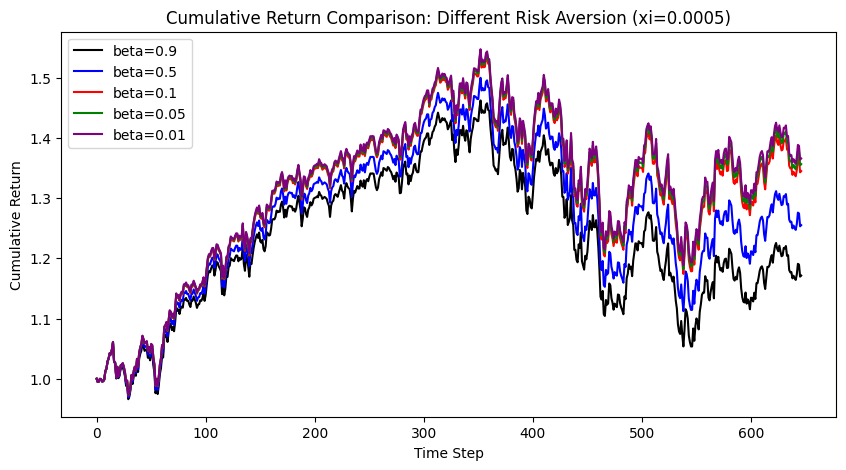


Performance Metrics for beta=0.01, xi=0.001:
Cumulative Return: 0.3631
Annualized Return: 0.1282
Annual Volatility: 0.1876
Sharpe Ratio: 0.6835
Maximum Drawdown: -0.2324
Calmar Ratio: 0.5518


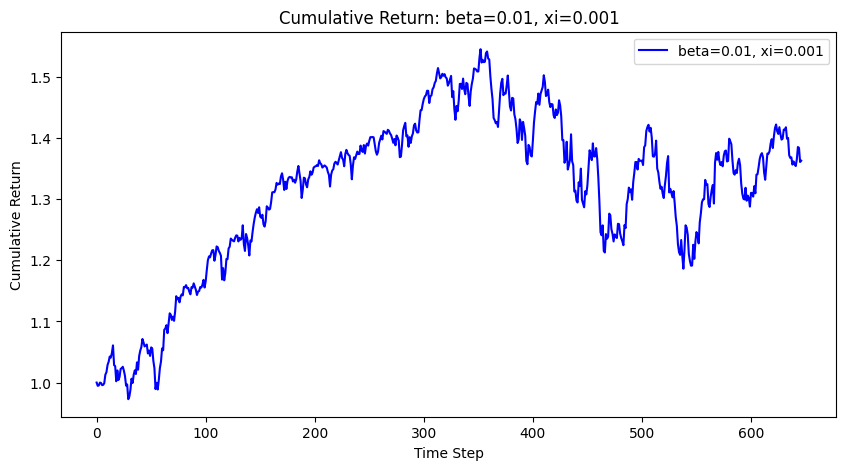

In [5]:
# -------------------------- Performance Metrics and Cumulative Return Comparisons --------------------------

def compute_cumulative_return(portfolio_values):
    """
    Computes the cumulative return over time.
    """
    portfolio_values = np.array(portfolio_values)
    return portfolio_values / portfolio_values[0]  # Normalize to start from 1.0

def run_td3_experiment(beta, xi, label, color=None):
    """
    Runs the TD3 agent with a given beta (risk aversion) and xi (transaction cost),
    and returns the portfolio values over time.
    """
    test_env = PortfolioEnv(df_test, beta=beta, xi=xi, window=5)
    state = test_env.reset()
    done = False
    portfolio_values = []

    while not done:
        action = td3_agent.select_action(state)
        state, reward, done, info = test_env.step(action)
        portfolio_values.append(info["portfolio_value"])

    cumulative_returns = compute_cumulative_return(portfolio_values)

    # Compute and print performance metrics
    metrics = compute_metrics(portfolio_values)
    print(f"\nPerformance Metrics for beta={beta}, xi={xi}:")
    for key, value in metrics.items():
        print(f"{key}: {value:.4f}")

    # Plot cumulative return
    plt.plot(cumulative_returns, label=label, color=color)

# -------------------------- Experiment 1: Different Transaction Costs for beta=0.005 --------------------------
plt.figure(figsize=(10, 5))
transaction_costs = [0.05, 0.01, 0.005, 0.001]  
colors = ['blue', 'red', 'green', 'purple']

for xi, color in zip(transaction_costs, colors):
    run_td3_experiment(beta=0.005, xi=xi, label=f"xi={xi}", color=color)

plt.title("Cumulative Return Comparison: Different Transaction Costs (beta=0.005)")
plt.xlabel("Time Step")
plt.ylabel("Cumulative Return")
plt.legend()
plt.show()

# -------------------------- Experiment 2: Different Risk Aversion for xi=0.0005 --------------------------
plt.figure(figsize=(10, 5))
betas = [0.9, 0.5, 0.1, 0.05, 0.01]  
colors = ['black', 'blue', 'red', 'green', 'purple']

for beta, color in zip(betas, colors):
    run_td3_experiment(beta=beta, xi=0.0005, label=f"beta={beta}", color=color)

plt.title("Cumulative Return Comparison: Different Risk Aversion (xi=0.0005)")
plt.xlabel("Time Step")
plt.ylabel("Cumulative Return")
plt.legend()
plt.show()

# -------------------------- Experiment 3: Single Condition (beta=0.01, xi=0.001) --------------------------
plt.figure(figsize=(10, 5))
run_td3_experiment(beta=0.01, xi=0.001, label="beta=0.01, xi=0.001", color='blue')

plt.title("Cumulative Return: beta=0.01, xi=0.001")
plt.xlabel("Time Step")
plt.ylabel("Cumulative Return")
plt.legend()
plt.show()

# TD3-LSTM Model

Starting training...
Episode: 0, Reward: 0.9185, Final Value: 1.9185
Episode: 1, Reward: 2.2923, Final Value: 3.2923
Episode: 2, Reward: 1.7276, Final Value: 2.7276
Episode: 3, Reward: 2.2627, Final Value: 3.2627
Episode: 4, Reward: 3.0326, Final Value: 4.0326
Episode: 5, Reward: 2.8104, Final Value: 3.8104
Episode: 6, Reward: 2.5523, Final Value: 3.5523
Episode: 7, Reward: 2.5008, Final Value: 3.5008
Episode: 8, Reward: 2.2838, Final Value: 3.2838
Episode: 9, Reward: 2.6672, Final Value: 3.6672
Episode: 10, Reward: 2.8602, Final Value: 3.8602
Episode: 11, Reward: 2.9542, Final Value: 3.9542
Episode: 12, Reward: 3.0837, Final Value: 4.0837
Episode: 13, Reward: 3.0704, Final Value: 4.0704
Episode: 14, Reward: 2.5466, Final Value: 3.5466
Episode: 15, Reward: 2.6548, Final Value: 3.6548
Episode: 16, Reward: 2.1069, Final Value: 3.1069
Episode: 17, Reward: 2.5516, Final Value: 3.5516
Episode: 18, Reward: 3.2064, Final Value: 4.2064
Episode: 19, Reward: 2.3974, Final Value: 3.3974
Episode: 

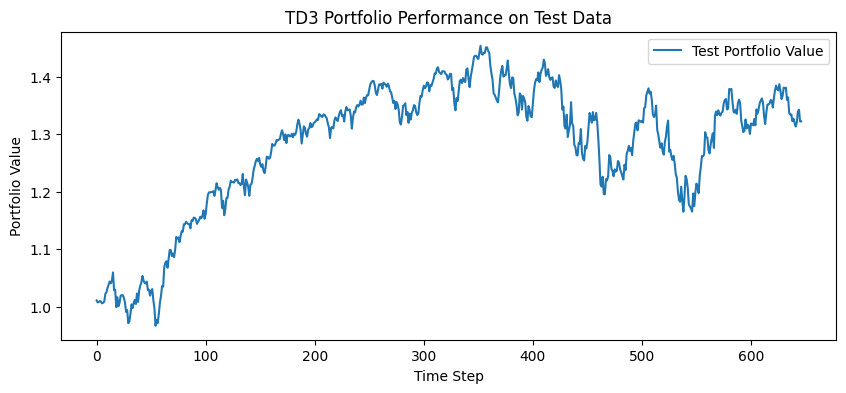

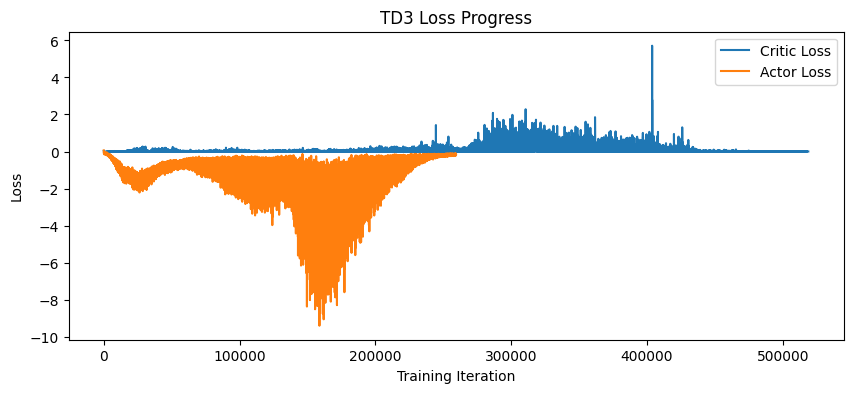

In [11]:
# TD3-LSTM model setting
class ActorLSTM(nn.Module):
    def __init__(self, state_dim, action_dim, max_action, hidden_size=512, num_layers=1):
        super(ActorLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size=state_dim, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, action_dim)
        self.max_action = max_action
    
    def forward(self, state, hidden=None):
        x = state.unsqueeze(1)  # (batch, 1, state_dim)
        lstm_out, hidden = self.lstm(x, hidden)  # lstm_out: (batch, 1, hidden_size)
        lstm_out = lstm_out[:, -1, :]  # (batch, hidden_size)
        a = torch.tanh(self.fc(lstm_out))
        return a * self.max_action, hidden


class TD3LSTM:
    def __init__(self, state_dim, action_dim, max_action, discount=0.98, tau=0.005,
                 policy_noise=0.02, noise_clip=0.05, policy_freq=2):
        self.actor = ActorLSTM(state_dim, action_dim, max_action).to(device)
        self.actor_target = ActorLSTM(state_dim, action_dim, max_action).to(device)
        self.actor_target.load_state_dict(self.actor.state_dict())
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=1e-4)
        
        self.critic = Critic(state_dim, action_dim).to(device)
        self.critic_target = Critic(state_dim, action_dim).to(device)
        self.critic_target.load_state_dict(self.critic.state_dict())
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=1e-4)
        
        self.max_action = max_action
        self.discount = discount
        self.tau = tau
        self.policy_noise = policy_noise
        self.noise_clip = noise_clip
        self.policy_freq = policy_freq
        self.total_it = 0
        
        # Track training losses for plotting
        self.train_log = {
            "critic_loss": [],
            "actor_loss": []
        }
    
    def select_action(self, state):
        state_tensor = torch.FloatTensor(state.reshape(1, -1)).to(device)  # (1, state_dim)
        action, _ = self.actor(state_tensor)
        return action.cpu().data.numpy().flatten()
    
    def train(self, replay_buffer, batch_size=64):
        self.total_it += 1
        state, action, reward, next_state, done = replay_buffer.sample(batch_size)
        
        # Target policy smoothing
        noise = (torch.randn_like(action) * self.policy_noise).clamp(-self.noise_clip, self.noise_clip)
        next_action, _ = self.actor_target(next_state)
        next_action = (next_action + noise).clamp(-self.max_action, self.max_action)
        
        target_Q1, target_Q2 = self.critic_target(next_state, next_action)
        target_Q = torch.min(target_Q1, target_Q2)
        target_Q = reward + ((1 - done) * self.discount * target_Q).detach()
        
        current_Q1, current_Q2 = self.critic(state, action)
        critic_loss = nn.MSELoss()(current_Q1, target_Q) + nn.MSELoss()(current_Q2, target_Q)
        
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()
        
        self.train_log["critic_loss"].append(critic_loss.item())
        
        if self.total_it % self.policy_freq == 0:
            actor_action, _ = self.actor(state)
            actor_loss = -self.critic.Q1(state, actor_action).mean()
            self.actor_optimizer.zero_grad()
            actor_loss.backward()
            self.actor_optimizer.step()
            
            self.train_log["actor_loss"].append(actor_loss.item())
            
            for param, target_param in zip(self.actor.parameters(), self.actor_target.parameters()):
                target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)
            for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
                target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)


# Execution
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    
    # Create training environment
    train_env = PortfolioEnv(df_train, beta=0.005, xi=0.0005, window=5)
    state_dim = train_env.observation_space.shape[0]
    action_dim = train_env.action_space.shape[0]
    max_action = 1.0
    
    # Initialize agent and replay buffer
    replay_buffer = ReplayBuffer(state_dim, action_dim)
    td3_agent = TD3LSTM(state_dim, action_dim, max_action) 
    
    # Train
    print("Starting training...")
    train_td3(train_env, td3_agent, replay_buffer,
              episodes=200,
              max_timesteps=len(df_train) - 5,
              batch_size=64,
              start_timesteps=1000)
    
    # Evaluate result
    test_env = PortfolioEnv(df_test, beta=0.005, xi=0.0005, window=5)
    state = test_env.reset()
    done = False
    portfolio_values = []
    
    if hasattr(td3_agent.actor, "reset_hidden"):
        td3_agent.actor.reset_hidden()  
    
    while not done:
        action = td3_agent.select_action(state)
        state, reward, done, info = test_env.step(action)
        portfolio_values.append(info["portfolio_value"])
    
    # Plot final test portfolio value progression
    plt.figure(figsize=(10,4))
    plt.plot(portfolio_values, label="Test Portfolio Value")
    plt.title("TD3 Portfolio Performance on Test Data")
    plt.xlabel("Time Step")
    plt.ylabel("Portfolio Value")
    plt.legend()
    plt.show()
    
    # -------------------------- Plot Training Losses --------------------------
    plt.figure(figsize=(10,4))
    plt.plot(td3_agent.train_log["critic_loss"], label="Critic Loss")
    plt.plot(td3_agent.train_log["actor_loss"], label="Actor Loss")
    plt.title("TD3 Loss Progress")
    plt.xlabel("Training Iteration")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


In [14]:
# -------------------------- Define Performance Metrics Calculation --------------------------
def compute_metrics(portfolio_values, trading_days=252):
    """
    Compute key performance metrics based on portfolio values over time.

    Parameters:
        portfolio_values (list or np.array): Daily portfolio values.
        trading_days (int): Number of trading days per year (default is 252).

    Returns:
        dict: A dictionary containing the computed performance metrics.
    """
    portfolio_values = np.array(portfolio_values)
    initial_value = portfolio_values[0]
    final_value = portfolio_values[-1]
    
    # 1) Cumulative Return: (Final - Initial) / Initial
    cumulative_return = (final_value - initial_value) / initial_value
    
    # 2) Annualized Return: (final/initial)^(trading_days/num_periods) - 1
    num_periods = len(portfolio_values)
    annualized_return = (final_value / initial_value) ** (trading_days / num_periods) - 1
    
    # 3) Compute Daily Returns
    daily_returns = portfolio_values[1:] / portfolio_values[:-1] - 1
    
    # 4) Annualized Volatility: Standard deviation of daily returns scaled by sqrt(trading_days)
    annual_volatility = np.std(daily_returns) * np.sqrt(trading_days)
    
    # 5) Sharpe Ratio (assuming zero risk-free rate)
    sharpe_ratio = annualized_return / annual_volatility if annual_volatility != 0 else np.nan
    
    # 6) Maximum Drawdown: Maximum drop from a running maximum
    cumulative_max = np.maximum.accumulate(portfolio_values)
    drawdowns = (portfolio_values - cumulative_max) / cumulative_max
    max_drawdown = drawdowns.min()  # Will be negative
    
    # 7) Calmar Ratio: Annualized return divided by the absolute maximum drawdown
    calmar_ratio = annualized_return / abs(max_drawdown) if max_drawdown != 0 else np.nan
    
    return {
        "Cumulative Return": cumulative_return,
        "Annualized Return": annualized_return,
        "Annual Volatility": annual_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": max_drawdown,
        "Calmar Ratio": calmar_ratio
    }

# -------------------------- Compute and Display Performance Metrics --------------------------
# Print the first 10 portfolio values to check for anomalies
print("First 10 portfolio values:", portfolio_values[:10])

# Compute performance metrics based on portfolio values
metrics = compute_metrics(portfolio_values)

# Print performance results
print("Performance Metrics:")
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")


First 10 portfolio values: [1.0106813188633161, 1.0071128996346328, 1.00799231796347, 1.0095555119589765, 1.0082229720155418, 1.0056029908510775, 1.006668403440146, 1.0087849559272786, 1.0220468287305609, 1.0250268839180077]
Performance Metrics:
Cumulative Return: 0.3080
Annualized Return: 0.1102
Annual Volatility: 0.1694
Sharpe Ratio: 0.6510
Maximum Drawdown: -0.1986
Calmar Ratio: 0.5552
